In [1]:
# %pip install --upgrade pip
# %pip install "scanpy>=1.10" anndata matplotlib numpy pandas igraph leidenalg

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

sc.settings.verbosity = 3
sc.set_figure_params(facecolor="white", figsize=(6, 6))

In [3]:
adata = sc.read_h5ad("../docs/Visium_Human_Breast_Cancer_filtered_feature_bc_matrix.h5ad")
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 4898 × 36601
    obs: 'in_tissue', 'array_row', 'array_col', 'imagecol', 'imagerow'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial'
    obsm: 'spatial'

In [4]:
print(adata.X.shape)                     # 1. 表达矩阵
print(adata.var['gene_ids'].shape)       # 2. 基因 ID
print(adata.obs['in_tissue'].shape)      # 3. 是否在组织中
print(adata.obsm['spatial'].shape)       # 4. 空间坐标

(4898, 36601)
(36601,)
(4898,)
(4898, 2)


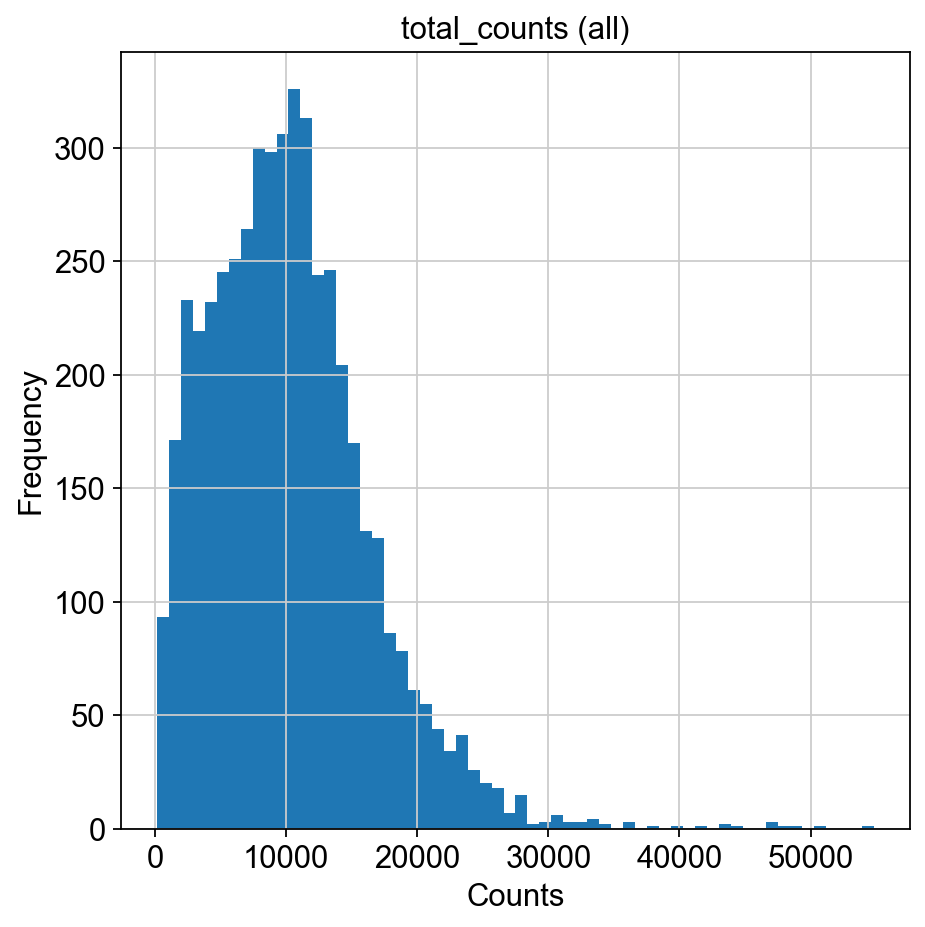

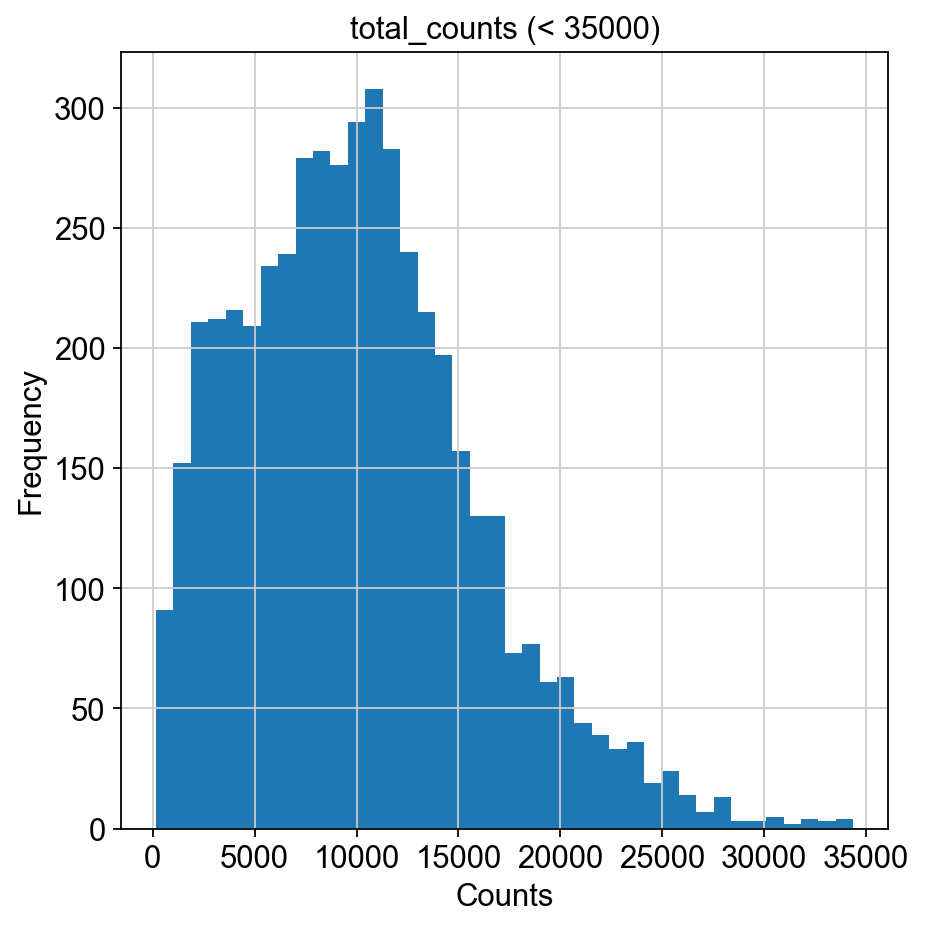

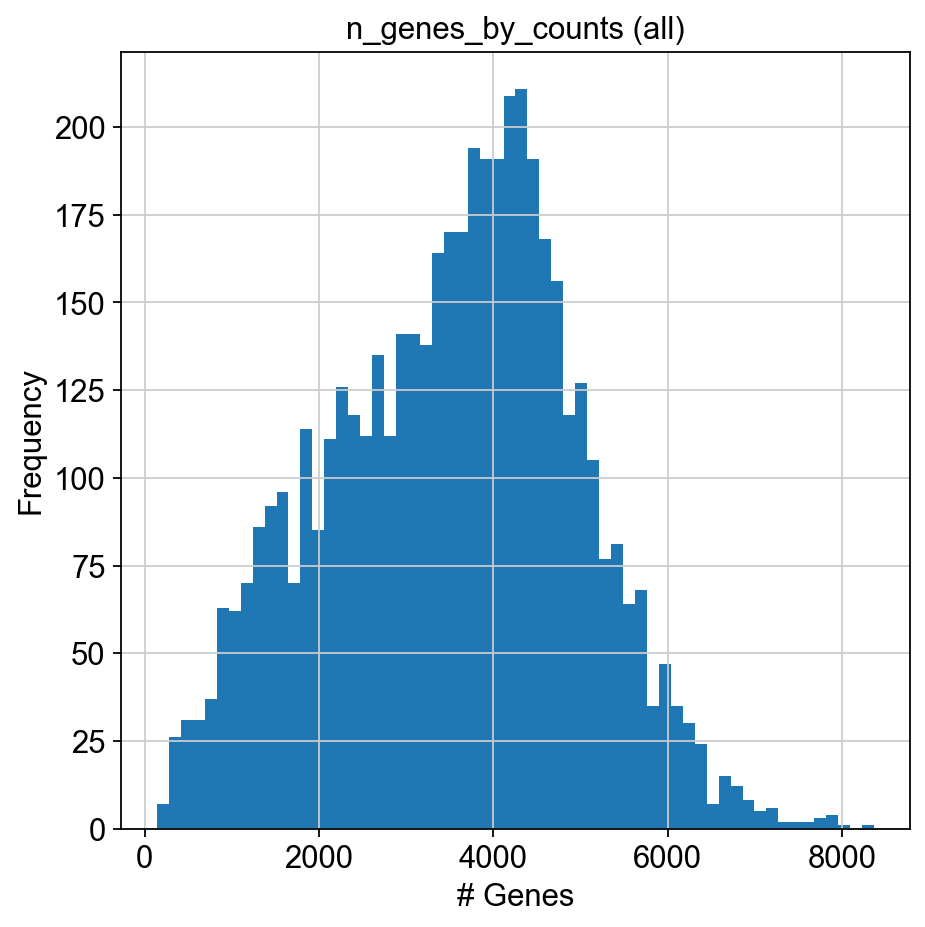

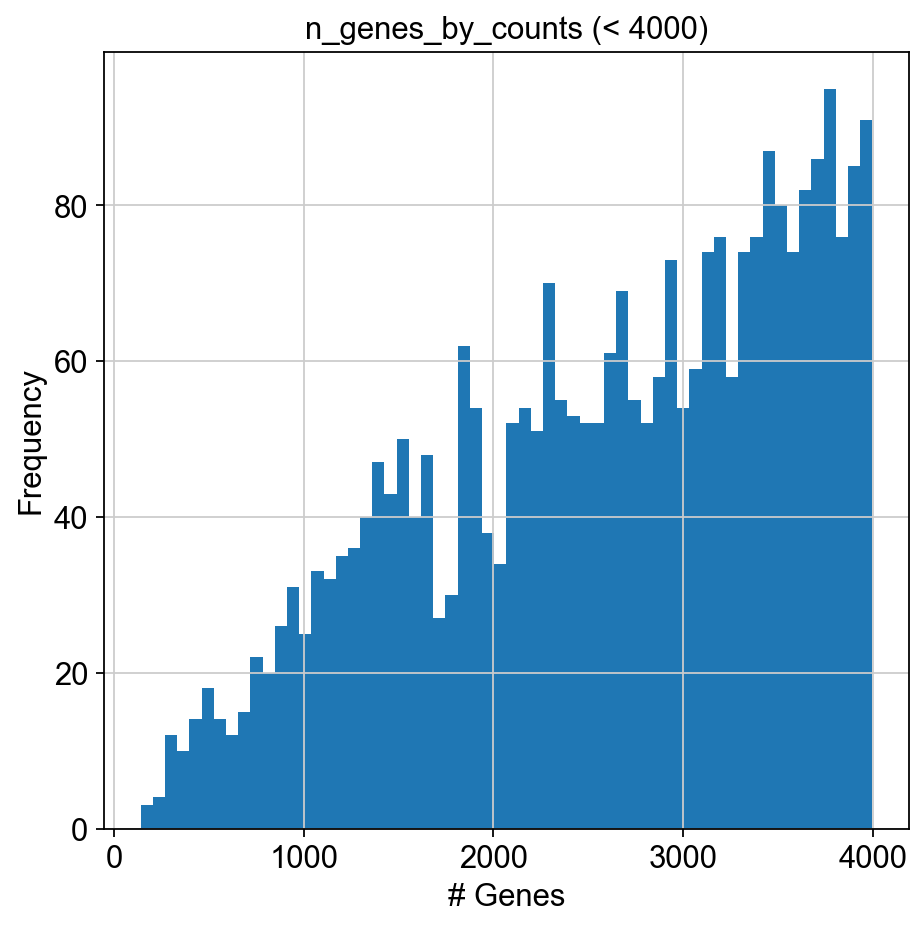

In [5]:

# Flag mitochondrial genes and compute QC metrics
adata.var["mt"] = adata.var_names.str.upper().str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)

# Histogram: total_counts (all)
plt.figure()
plt.hist(adata.obs["total_counts"], bins=60)
plt.title("total_counts (all)")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Histogram: total_counts (< 35000)
plt.figure()
vals = adata.obs["total_counts"]
plt.hist(vals[vals < 35000], bins=40)
plt.title("total_counts (< 35000)")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Histogram: n_genes_by_counts (all)
plt.figure()
plt.hist(adata.obs["n_genes_by_counts"], bins=60)
plt.title("n_genes_by_counts (all)")
plt.xlabel("# Genes")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Histogram: n_genes_by_counts (< 4000)
plt.figure()
vals2 = adata.obs["n_genes_by_counts"]
plt.hist(vals2[vals2 < 4000], bins=60)
plt.title("n_genes_by_counts (< 4000)")
plt.xlabel("# Genes")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [6]:
sc.pp.filter_cells(adata, min_counts=5000)
sc.pp.filter_cells(adata, max_counts=35000)
adata = adata[adata.obs["pct_counts_mt"] < 20].copy()
print("#spots after MT filter:", adata.n_obs)
sc.pp.filter_genes(adata, min_cells=10)
print("After gene filter, n_vars:", adata.n_vars)

filtered out 1027 cells that have less than 5000 counts
filtered out 16 cells that have more than 35000 counts
#spots after MT filter: 3855
filtered out 18143 genes that are detected in less than 10 cells
After gene filter, n_vars: 18458


In [7]:
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)
print("HVGs identified:", int(adata.var["highly_variable"].sum()))

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
HVGs identified: 2000


In [8]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(
    adata, key_added="clusters", flavor="igraph",
    directed=False, n_iterations=2, resolution=1.0
)
print("Leiden clusters:", adata.obs["clusters"].unique().tolist())

computing PCA
    with n_comps=50
    finished (0:00:01)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:04)
running Leiden clustering
    finished: found 16 clusters and added
    'clusters', the cluster labels (adata.obs, categorical) (0:00:00)
Leiden clusters: ['0', '1', '2', '4', '6', '5', '7', '3', '8', '11', '9', '10', '13', '14', '15', '12']


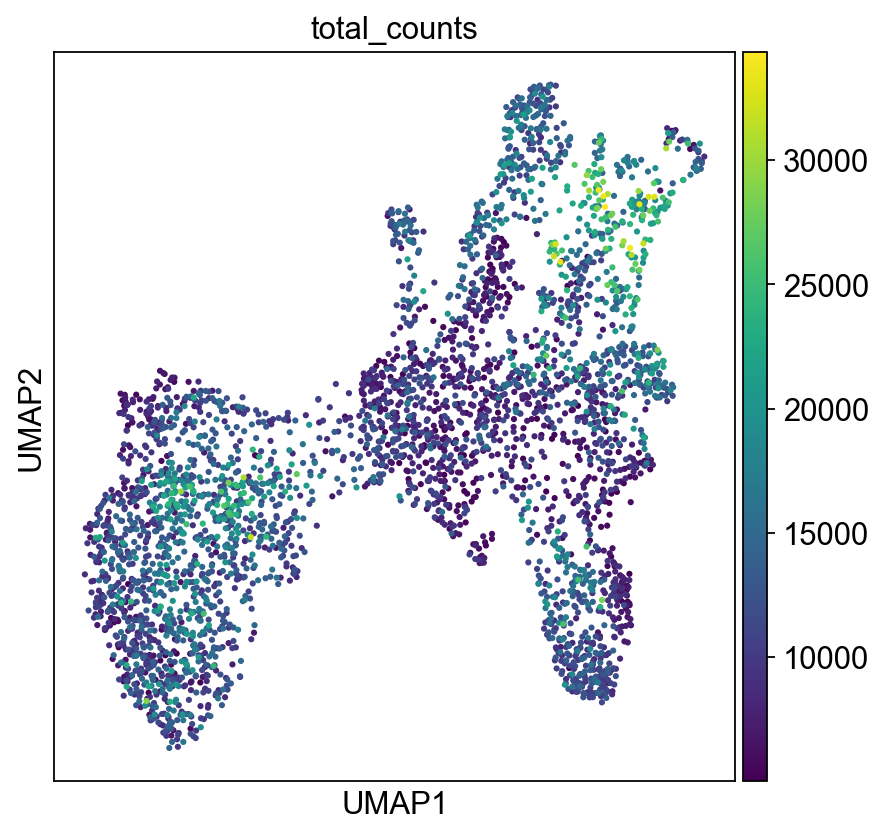

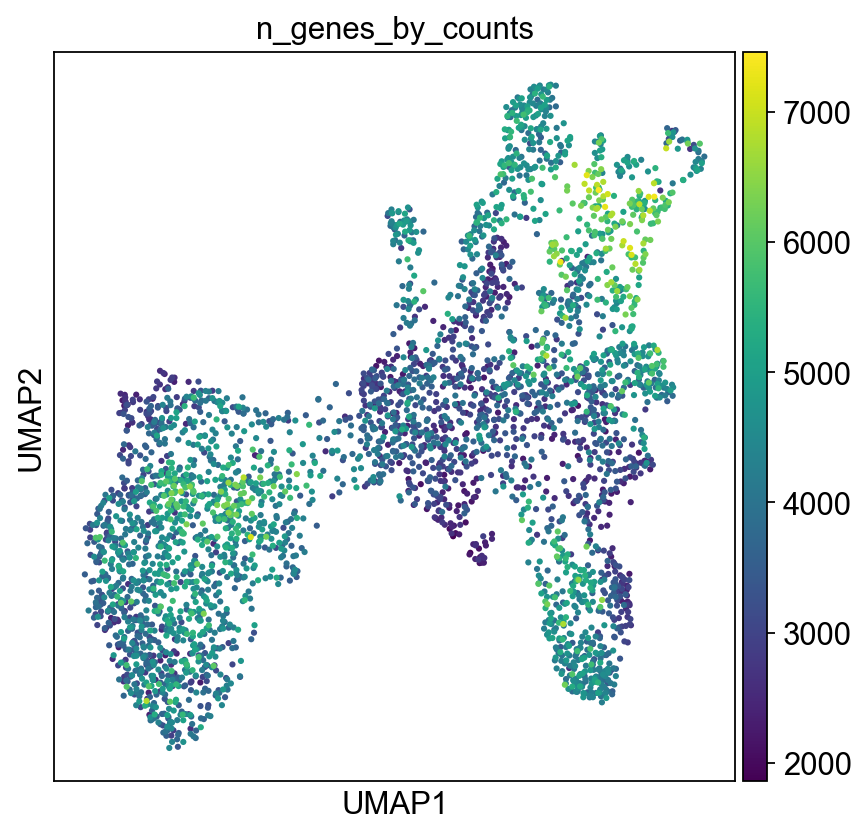

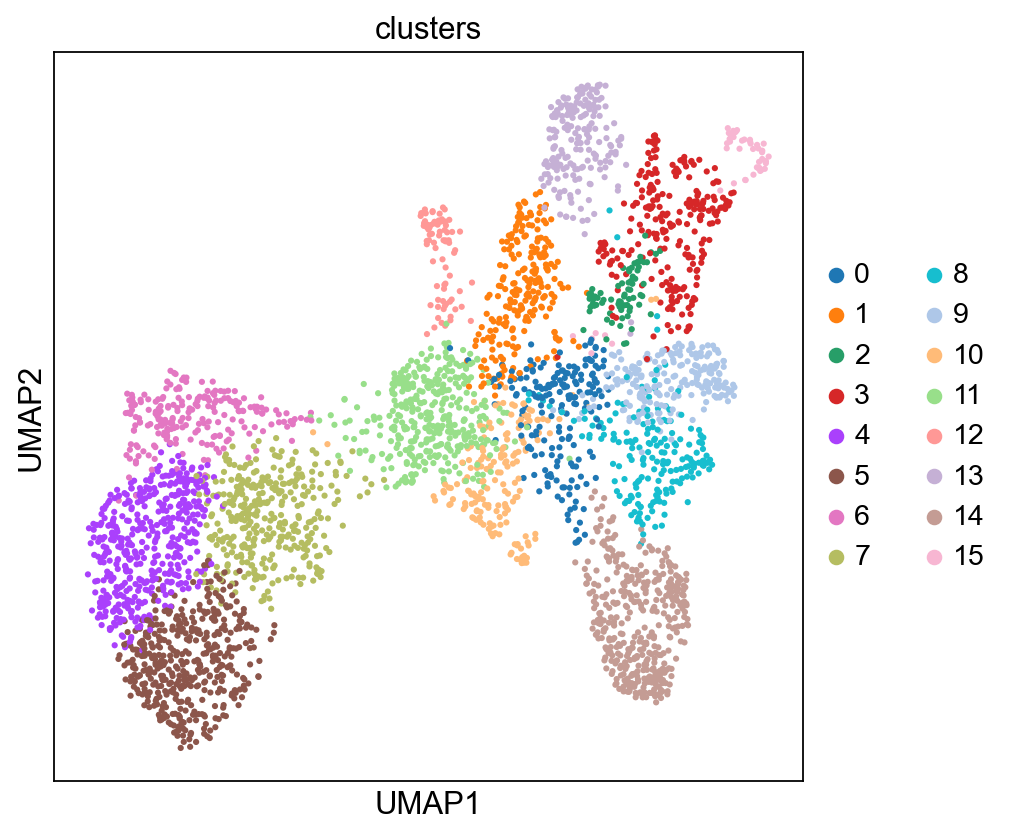

In [9]:
# UMAP plots
sc.pl.umap(adata, color=["total_counts"], wspace=0.4)
sc.pl.umap(adata, color=["n_genes_by_counts"], wspace=0.4)
sc.pl.umap(adata, color=["clusters"], wspace=0.4)

/var/folders/w2/jm4sr6hx73bdcs3t0f0d0x9h0000gn/T/ipykernel_51786/833416663.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["total_counts"])


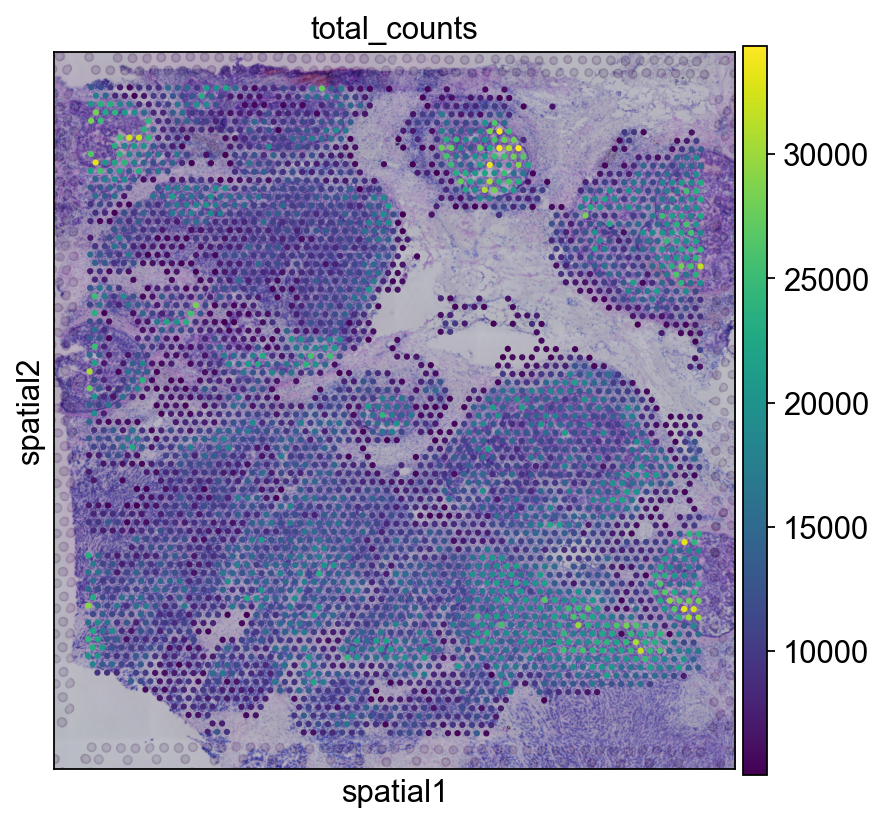

/var/folders/w2/jm4sr6hx73bdcs3t0f0d0x9h0000gn/T/ipykernel_51786/833416663.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color=["n_genes_by_counts"])


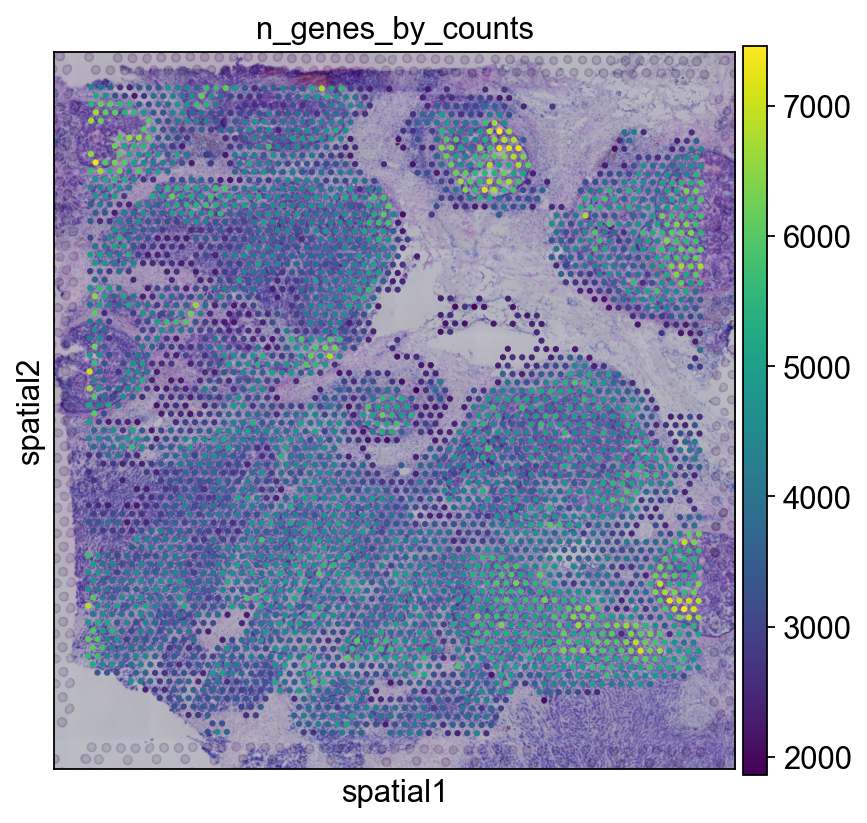

/var/folders/w2/jm4sr6hx73bdcs3t0f0d0x9h0000gn/T/ipykernel_51786/833416663.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, color="clusters", size=1.5)


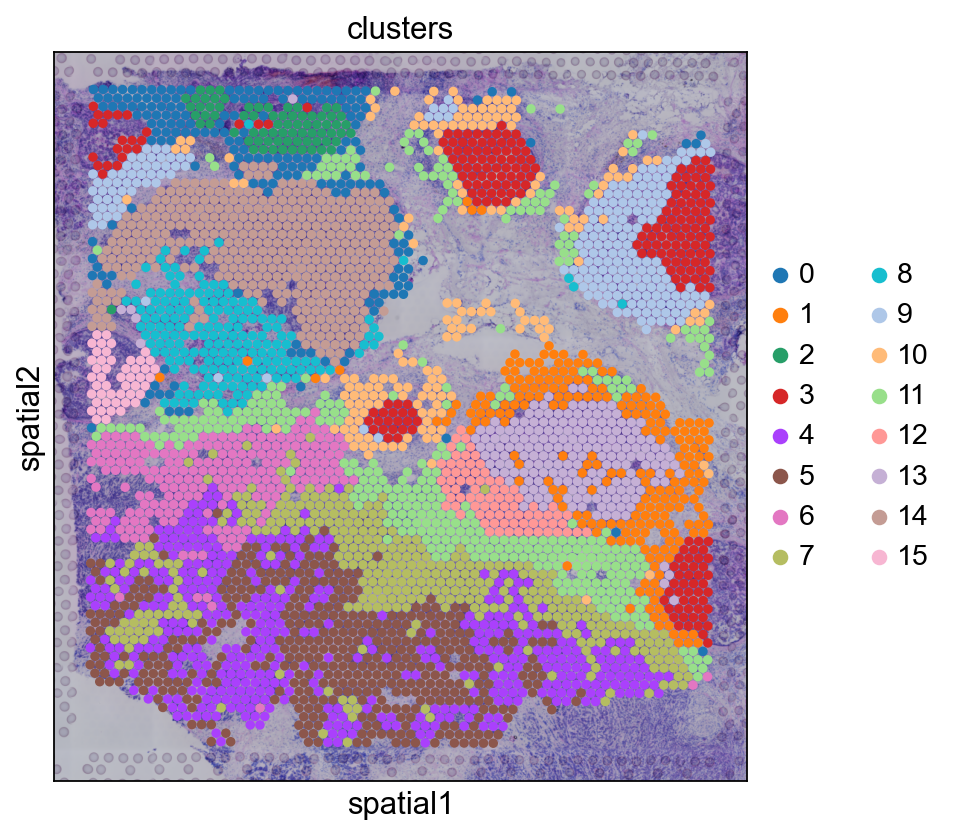

In [10]:
# Spatial QC overlays
sc.pl.spatial(adata, color=["total_counts"])
sc.pl.spatial(adata, color=["n_genes_by_counts"])
sc.pl.spatial(adata, color="clusters", size=1.5)

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
    using 'X_pca' with n_pcs = 50
Storing dendrogram info using `.uns['dendrogram_clusters']`


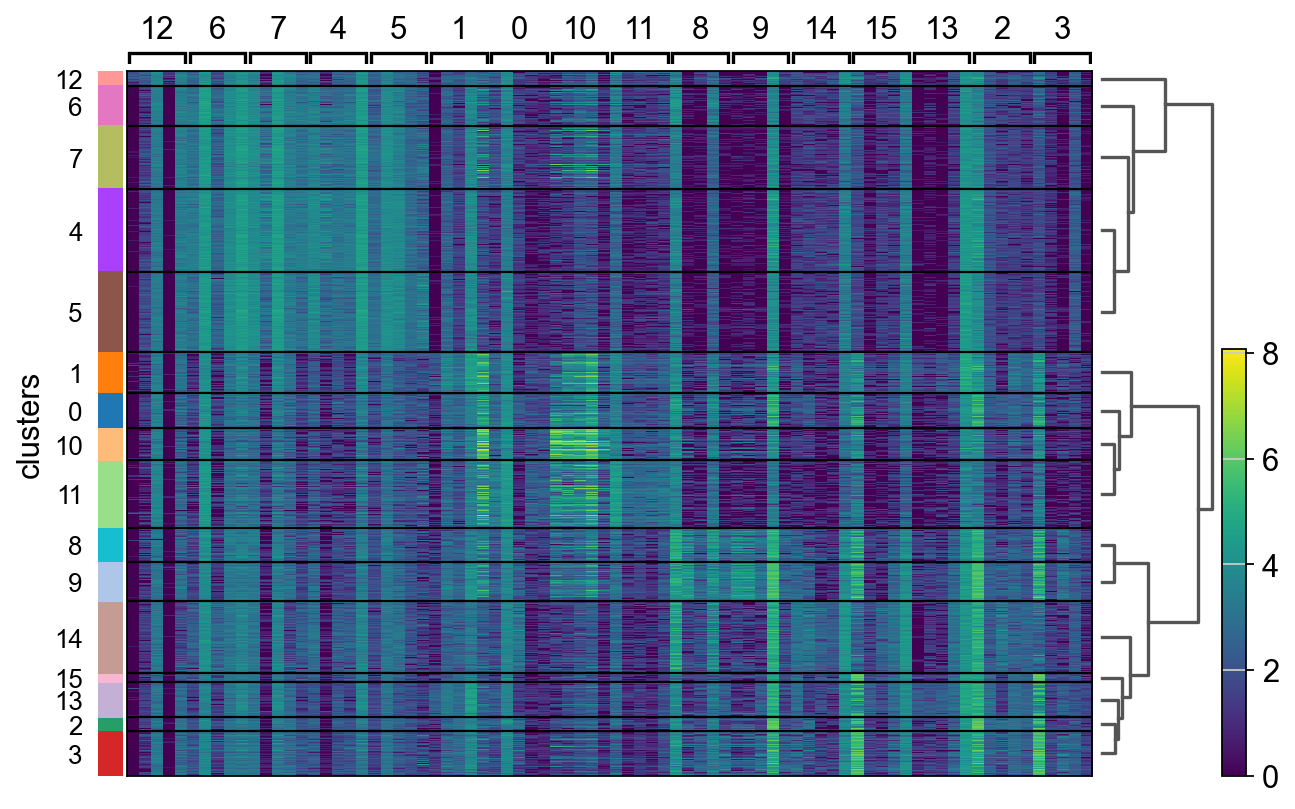

In [11]:
# Marker genes for one cluster (e.g., top genes for each cluster)
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")
sc.pl.rank_genes_groups_heatmap(
    adata, groups=None, n_genes=5, groupby="clusters")